--- 1. RÉGRESSION LINÉAIRE SIMPLE: y = ax + b ---
  [Scratch]  Biais: -126200.00  |  Coef: 4907.27
  [sklearn]  Biais: -126200.00  |  Coef: 4907.27

--- 2. RÉGRESSION LINÉAIRE MULTIPLE: y = a1x1 + a2x2 + b ---
  [Scratch]  Biais: -119650.00  |  Coefs: [  5860. -19650.]
  [sklearn]  Biais: -119650.00  |  Coefs: [  5860. -19650.]

--- 3. RÉGRESSION POLYNOMIALE (Degré 2) ---
  [Scratch]  Coefs (Biais, X, X²): [67383.33333333 -4771.89393939    87.99242424]
  [sklearn]  Biais: 67383.33  |  Coefs: [-4771.89393939    87.99242424]

--- 4. RÉGRESSION LOGISTIQUE ---
w = 0.017074081898158514
b = -0.176960294220234


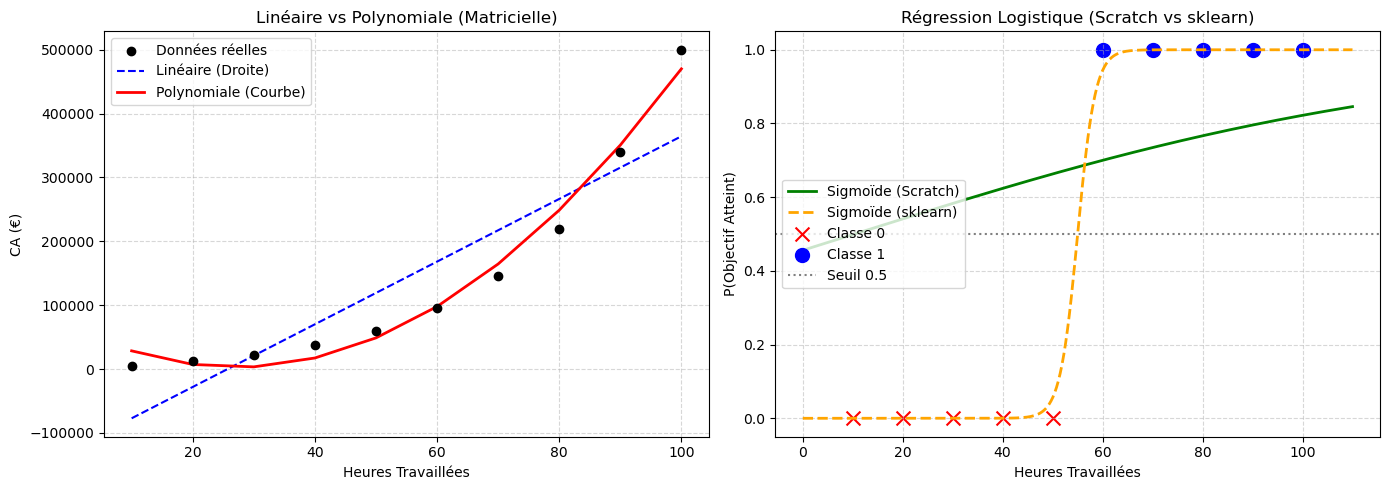

In [6]:
# Nom : [raji]    Prenom : [ Ismail]    Master : GLCC

import numpy as np                      # ici on importe numpy pour faire des calculs mathématiques
import matplotlib.pyplot as plt         # ici on importe matplotlib pour afficher des graphiques


# ================================================================= DONNÉES
X_simple   = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])   # ici on définit une seule variable (heures par exemple)
X_multiple = np.array([[10,1],[20,1],[30,2],[40,2],[50,3],[60,3],[70,4],[80,4],[90,5],[100,5]])  # ici on a deux variables (ex: heures + niveau)
y_reg      = np.array([5000,12000,22000,38000,60000,95000,145000,220000,340000,500000])  # ici c'est la valeur à prédire (ex: salaire)
y_clf      = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])   # ici c'est la classification (0 = non atteint, 1 = atteint)

# ====================== ÉQUATION NORMALE
def fit_scratch(X, y):
    X_b = np.c_[np.ones((len(X), 1)), X]        # ici on ajoute une colonne de 1 pour le biais
    return np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)   # puis on applique la formule mathématique pour trouver les paramètres

sigmoid = lambda z: 1 / (1 + np.exp(-z))   # ici on définit la fonction sigmoïde pour transformer en probabilité

# ================================================= 1. LINÉAIRE SIMPLE
print("--- 1. RÉGRESSION LINÉAIRE SIMPLE: y = ax + b ---")

theta_s = fit_scratch(X_simple.reshape(-1,1), y_reg)   # ici on calcule les paramètres avec notre méthode
print(f"  [Scratch]  Biais: {theta_s[0]:.2f}  |  Coef: {theta_s[1]:.2f}")  # puis on affiche le résultat

lr_s = LinearRegression().fit(X_simple.reshape(-1,1), y_reg)   # ici on utilise sklearn pour comparer
print(f"  [sklearn]  Biais: {lr_s.intercept_:.2f}  |  Coef: {lr_s.coef_[0]:.2f}\n")  # affichage

# ================================================= 2. LINÉAIRE MULTIPLE
print("--- 2. RÉGRESSION LINÉAIRE MULTIPLE: y = a1x1 + a2x2 + b ---")

theta_m = fit_scratch(X_multiple, y_reg)   # ici on applique la même méthode mais avec plusieurs variables
print(f"  [Scratch]  Biais: {theta_m[0]:.2f}  |  Coefs: {theta_m[1:]}")

lr_m = LinearRegression().fit(X_multiple, y_reg)   # puis comparaison avec sklearn
print(f"  [sklearn]  Biais: {lr_m.intercept_:.2f}  |  Coefs: {lr_m.coef_}\n")

# ================================================= 3. POLYNOMIALE (Degré 2)
print("--- 3. RÉGRESSION POLYNOMIALE (Degré 2) ---")

# ici on crée manuellement une nouvelle variable x² pour capturer une courbe
theta_p = fit_scratch(np.c_[X_simple, X_simple**2], y_reg)
print(f"  [Scratch]  Coefs (Biais, X, X²): {theta_p}")

# puis on fait la même chose avec sklearn
lr_p = LinearRegression().fit(PolynomialFeatures(2, include_bias=False).fit_transform(X_simple.reshape(-1,1)), y_reg)
print(f"  [sklearn]  Biais: {lr_p.intercept_:.2f}  |  Coefs: {lr_p.coef_}\n")

# ================================================= 4. LOGISTIQUE
print("--- 4. RÉGRESSION LOGISTIQUE ---")

# -------------------------
# 1. DATA
# -------------------------
X = np.array([10,20,30,40,50,60,70,80,90,100])   # ici les données d'entrée
y = np.array([0,0,0,0,0,1,1,1,1,1])              # ici les classes (0 ou 1)

# -------------------------
# 2. INITIALISATION
# -------------------------
w = 0.0                 # ici on initialise le poids
b = 0.0                 # ici on initialise le biais
learning_rate = 0.0001  # ici le taux d’apprentissage (petit pour éviter les erreurs)
epochs = 10000          # ici le nombre d’itérations

# -------------------------
# 3. SIGMOID
# -------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))   # ici on transforme en probabilité

# -------------------------
# 4. TRAINING
# -------------------------
for i in range(epochs):   # ici on répète plusieurs fois
    
    z = w * X + b         # ici on calcule la combinaison linéaire
    
    y_pred = sigmoid(z)   # puis on applique la sigmoïde
    
    dw = np.mean((y_pred - y) * X)   # ici on calcule le gradient pour w
    db = np.mean(y_pred - y)         # ici pour le biais
    
    w = w - learning_rate * dw   # ici on met à jour w
    b = b - learning_rate * db   # puis b

# -------------------------
# 5. PARAMÈTRES FINAUX
# -------------------------
print("w =", w)   # affichage du poids final
print("b =", b)   # affichage du biais final

# ================================================= 5. VISUALISATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))   # ici on crée deux graphiques

# Graphique 1
ax1.scatter(X_simple, y_reg, color='black', zorder=5, label='Données réelles')  # ici les points réels
ax1.plot(X_simple, theta_s[0] + theta_s[1]*X_simple, 'b--', label='Linéaire (Droite)')  # droite
ax1.plot(X_simple, theta_p[0] + theta_p[1]*X_simple + theta_p[2]*X_simple**2, 'r', lw=2, label='Polynomiale (Courbe)')  # courbe
ax1.set(title='Linéaire vs Polynomiale (Matricielle)', xlabel='Heures Travaillées', ylabel='CA (€)')
ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.5)   # ici on ajoute grille et légende

# Graphique 2
Xr = np.linspace(0, 110, 300)   # ici on crée des valeurs pour tracer la courbe
Xr_b = np.c_[np.ones(len(Xr)), Xr]   # ajout du biais

ax2.plot(Xr, sigmoid(Xr_b.dot(th_l)), 'g', lw=2, label='Sigmoïde (Scratch)')   # courbe sigmoïde scratch
ax2.plot(Xr, log_sk.predict_proba(Xr.reshape(-1,1))[:,1], 'orange', lw=2, ls='--', label='Sigmoïde (sklearn)')  # sklearn

ax2.scatter(X_simple[y_clf==0], y_clf[y_clf==0], color='red',  marker='x', s=100, label='Classe 0')   # points classe 0
ax2.scatter(X_simple[y_clf==1], y_clf[y_clf==1], color='blue', marker='o', s=100, label='Classe 1')  # points classe 1

ax2.axhline(0.5, color='grey', ls=':', label='Seuil 0.5')   # ligne seuil
ax2.set(title='Régression Logistique (Scratch vs sklearn)', xlabel='Heures Travaillées', ylabel='P(Objectif Atteint)')
ax2.legend(loc='center left'); ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(); plt.show()   # ici on affiche tout proprement